# **Tensorflow VS Keras**

Tensorflow is a low-level library like NumPy. Keras is a high-level API built on top of a low-level library or framework. Nowadays mostly done on Tensorflow.

Tensorflow is a rich low-level ecosystem and Keras brings an easy-to-use layer of abstraction to it.

## **Load Dataset**

From Tensorflow directly. Later also from CSV.

In [1]:
import tensorflow as tf

In [2]:
from re import X
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
X_train, X_test = X_train /255.0, X_test /255.0

In [8]:
X_train.shape

(60000, 28, 28)

In [9]:
X_test.shape

(10000, 28, 28)

In [10]:
y_test.shape

(10000,)

In [11]:
y_train.shape

(60000,)

In [13]:
X_train[0]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000

## **Build Model / Architecture**

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

model = Sequential()
model.add(Input((28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10))

In [15]:
nonsense_prediction = model(X_train[:1]).numpy()
nonsense_prediction

array([[-0.00284995,  0.00087984, -0.00071742, -0.00251785,  0.00299481,
         0.00098952, -0.00136484, -0.00103263, -0.00285358, -0.00184189]],
      dtype=float32)

In [16]:
tf.nn.softmax(nonsense_prediction).numpy()

array([[0.09979817, 0.1001711 , 0.10001122, 0.09983132, 0.10038318,
        0.10018209, 0.09994649, 0.09997971, 0.09979782, 0.09989882]],
      dtype=float32)

In [18]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy

loss_fn = SparseCategoricalCrossentropy(from_logits=True)

expected_loss = -tf.math.log(1/10)

print('Expected loss on random guess', expected_loss)
print('Actual loss:', loss_fn(y_train[:1], nonsense_prediction))

Expected loss on random guess tf.Tensor(2.3025851, shape=(), dtype=float32)
Actual loss: tf.Tensor(2.300766, shape=(), dtype=float32)


## **Compile & Train Model**

In [19]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.01)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8367 - loss: 0.5470
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9162 - loss: 0.2814
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9321 - loss: 0.2313
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9406 - loss: 0.1997
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9455 - loss: 0.1800
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9481 - loss: 0.1673
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9520 - loss: 0.1572
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9548 - loss: 0.1467
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9556 - loss: 0.1425
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9589 - loss: 0.1321
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9599 - loss: 0.1296
Epoch 12/20
1875/1875 ━━━━━━━

### **Evaluate Model**

In [20]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9695 - loss: 0.1047


[0.1046895757317543, 0.9695000052452087]

In [21]:
tf.argmax(tf.nn.softmax(model(X_test[:1])), axis=1)

<tf.Tensor: shape=(1,), dtype=int64, numpy=array([7])>

In [22]:
y_test[:1]

array([7], dtype=uint8)

In [23]:
predictions = tf.argmax(tf.nn.softmax(model(X_test[:10])), axis=1)
print("Predicted:", predictions.numpy())
print("Actual:   ", y_test[:10])

Predicted: [7 2 1 0 4 1 4 9 6 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


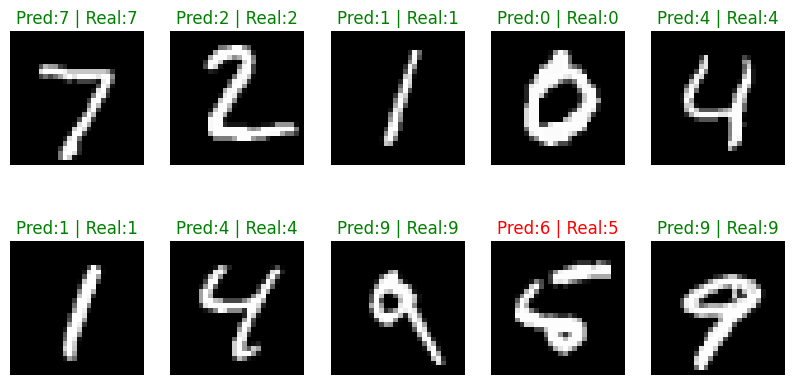

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    pred = tf.argmax(tf.nn.softmax(model(X_test[i:i+1])), axis=1).numpy()[0]
    actual = y_test[i]
    ax.set_title(f"Pred:{pred} | Real:{actual}",
                 color='green' if pred==actual else 'red')
    ax.axis('off')
plt.show()

In [25]:
predictions = tf.argmax(tf.nn.softmax(model(X_test)), axis=1).numpy()
wrong = [i for i in range(len(y_test)) if predictions[i] != y_test[i]]
print(f"Total wrong: {len(wrong)} out of {len(y_test)}")

Total wrong: 305 out of 10000


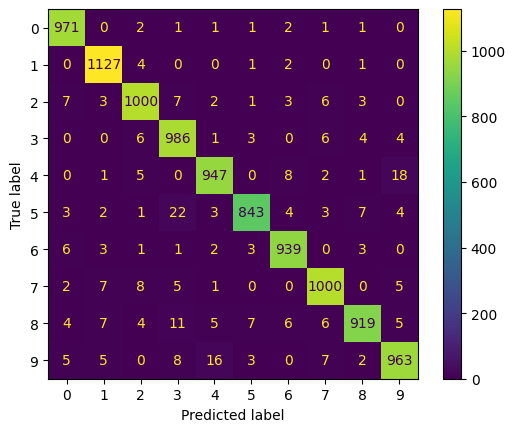

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = tf.argmax(tf.nn.softmax(model(X_test)), axis=1).numpy()
cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm).plot()
plt.show()